In [ ]:
import numpy as np
import pandas as pd
df = pd.read_excel("/content/dataaaaaaaa.xlsx")
df = df.drop(columns=['obs','month','month_num','year'])
df = df.dropna().reset_index(drop=True)
df.shape
X = df.drop(columns=['CPI_IDX'])
y = df['CPI_IDX']
print(df)
# df['unemployment'] = np.log(df['unemployment'])
# df['EX_AVG_USD'] = np.log(df['EX_AVG_USD'])
# df['policy'] = np.log(df['policy'])

# print(df.head())

     CPI_IDX  EX_AVG_USD  EXI_IDX  IMI_IDX        M2  policy  oilwtiprice  \
0      90.16     32.7344     94.8     87.0  16947602    2.00        48.24   
1      90.26     32.5734     95.0     87.2  17113914    2.00        49.76   
2      90.42     32.6314     95.1     86.7  17193104    1.75        47.60   
3      90.43     32.5095     95.2     87.3  17166475    1.50        59.63   
4      90.58     33.5519     95.5     88.0  17190904    1.50        60.30   
..       ...         ...      ...      ...       ...     ...          ...   
100   100.94     34.7568    110.7    112.8  25577526    2.50        73.55   
101   100.84     33.3626    110.8    112.3  25793826    2.50        68.17   
102   100.77     33.3638    111.0    113.1  26194851    2.50        69.26   
103   100.64     34.4455    110.6    112.5  26280476    2.25        68.00   
104   100.47     34.1885    110.8    112.9  26340781    2.25        71.72   

     unemployment  PPI_IDX      GOLD  
0            1.06     99.7  19407.69

In [ ]:
# from scipy.stats import chi2_contingency
# def test_independence(df):
#     results = {}
#     cols = df.columns
#     for i in range(len(cols)):
#         for j in range(i+1, len(cols)):
#             crosstab = pd.crosstab(df[cols[i]], df[cols[j]])
#             chi2, p, dof, ex = chi2_contingency(crosstab)
#             results[(cols[i], cols[j])] = {'chi2': chi2, 'p_value': p, 'dof': dof}
#     return results

# # Run test
# independence_results = test_independence(df)

# # Print results
# for pair, res in independence_results.items():
#     print(f"Independence test for {pair[0]} and {pair[1]}:")
#     print(f"  Chi-square statistic = {res['chi2']:.4f}, p-value = {res['p_value']:.4f}")
#     if res['p_value'] < 0.05:
#         print("  --> Variables are likely dependent")
#     else:
#         print("  --> Variables are likely independent")

# dependent variable
# import and export
# policy and ppi
# export and ppi

Text(0.5, 1.0, 'Correlation Heatmap Pearson')

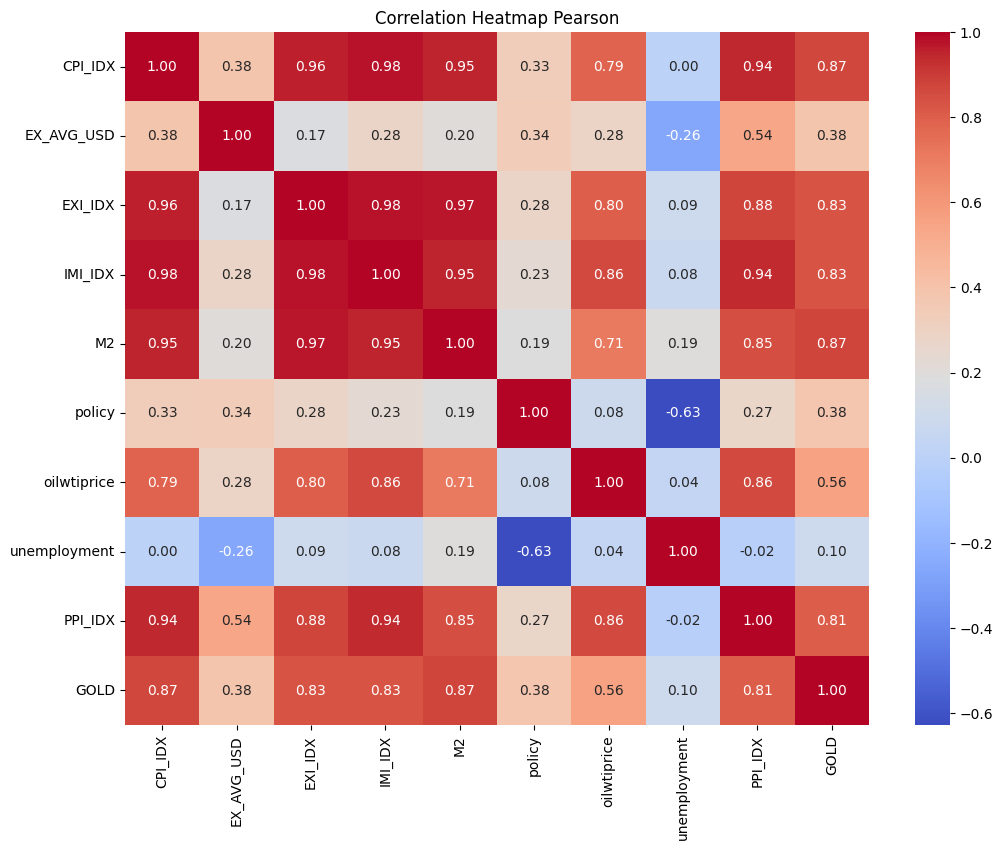

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
nu_df = df.select_dtypes(include = [np.number])
plt.figure(figsize = (12,9))
corr = nu_df.corr(method = 'pearson')
sns.heatmap(corr , fmt = '.2f' , annot = True , cmap = 'coolwarm' )
plt.title('Correlation Heatmap Pearson')

# sns.pairplot(df)

In [ ]:
from scipy.stats import shapiro, anderson, normaltest
from scipy import stats
from sklearn.preprocessing import RobustScaler

alpha = 0.05

for feature in df.columns:
    if feature == 'policy' :
      continue
    else :
      data = df[feature].dropna()

      print(f'Feature: {feature}')

      # Shapiro-Wilk test
      stat_sw, p_sw = shapiro(data)
      print(f'Shapiro-Wilk test: Statistic={stat_sw:.3f}, p={p_sw:.3f}', end='; ')
      if p_sw > alpha:
          print("Normality assumed")
      else:
          print("Normality rejected")

      # Anderson-Darling test
      result_ad = anderson(data)
      print(f'Anderson-Darling test: Statistic={result_ad.statistic:.3f}')
      for i in range(len(result_ad.critical_values)):
          sl, cv = result_ad.significance_level[i], result_ad.critical_values[i]
          if result_ad.statistic < cv:
              print(f'  Significance level {sl}%, normality assumed')
          else:
              print(f'  Significance level {sl}%, normality rejected')

      # D’Agostino’s K-squared test (normaltest)
      stat_dt, p_dt = normaltest(data)
      print(f"D'Agostino's K^2 test: Statistic={stat_dt:.3f}, p={p_dt:.3f}", end='; ')
      if p_dt > alpha:
          print("Normality assumed")
      else:
          print("Normality rejected")

      print('--------------------------------------------')

Feature: CPI_IDX
Shapiro-Wilk test: Statistic=0.793, p=0.000; Normality rejected
Anderson-Darling test: Statistic=9.439
  Significance level 15.0%, normality rejected
  Significance level 10.0%, normality rejected
  Significance level 5.0%, normality rejected
  Significance level 2.5%, normality rejected
  Significance level 1.0%, normality rejected
D'Agostino's K^2 test: Statistic=106.688, p=0.000; Normality rejected
--------------------------------------------
Feature: EX_AVG_USD
Shapiro-Wilk test: Statistic=0.969, p=0.014; Normality rejected
Anderson-Darling test: Statistic=1.014
  Significance level 15.0%, normality rejected
  Significance level 10.0%, normality rejected
  Significance level 5.0%, normality rejected
  Significance level 2.5%, normality rejected
  Significance level 1.0%, normality assumed
D'Agostino's K^2 test: Statistic=13.313, p=0.001; Normality rejected
--------------------------------------------
Feature: EXI_IDX
Shapiro-Wilk test: Statistic=0.903, p=0.000; Nor

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pylab


def calculate_vif(df):
    df_with_const = sm.add_constant(df)
    vif_df = pd.DataFrame()
    vif_df['Column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df_with_const.values, i + 1) for i in range(df.shape[1])]
    return vif_df
# Backward elimination function
def backward_elimination(X, y, threshold_out=0.05, verbose=True):
    included = list(X.columns)
    while included:
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        pvalues = model.pvalues.iloc[1:]  # Exclude constant
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f'Remove {worst_feature} with p-value {worst_pval:.6f}')
        else:
            break
    return included

def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.05, verbose=True):

    included = []  # เริ่มจากโมเดลว่าง
    excluded = list(X.columns)  # ตัวแปรทั้งหมดที่ยังไม่ได้เลือก

    while True:
        changed = False

        # Forward Selection: ลองเพิ่มตัวแปรที่เหลือทีละตัว
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_feature in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_feature]])).fit()
            new_pval[new_feature] = model.pvalues[new_feature]

        best_pval = new_pval.min()
        if best_pval < threshold_in:  # ถ้ามีตัวแปรที่ p-value < threshold_in
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            excluded.remove(best_feature)
            changed = True
            if verbose:
                print(f'Add {best_feature} with p-value {best_pval:.6f}')

        # Backward Elimination: ตรวจสอบตัวแปรที่อยู่ในโมเดล
        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]  # Exclude constant
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:  # ถ้ามีตัวแปรที่ p-value > threshold_out
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                excluded.append(worst_feature)
                changed = True
                if verbose:
                    print(f'Remove {worst_feature} with p-value {worst_pval:.6f}')

        # ถ้าไม่มีอะไรเปลี่ยนแปลง (ไม่เพิ่มหรือลบตัวแปร) ออกจาก loop
        if not changed:
            break

    return included


def diagnostic_plots(df, variable):
    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15,6))
    plt.subplot(1, 2, 1)
    df[variable].hist()

    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=pylab)

    plt.show()

In [ ]:
selected_features = backward_elimination(X, y)
print("\nSelected features (after backward elimination):", selected_features)
X_selected = X[selected_features]


Remove EXI_IDX with p-value 0.993226
Remove PPI_IDX with p-value 0.905186
Remove GOLD with p-value 0.542345

Selected features (after backward elimination): ['EX_AVG_USD', 'IMI_IDX', 'M2', 'policy', 'oilwtiprice', 'unemployment']


In [ ]:
# df['IMI_IDX_log'] = np.log1p(df['IMI_IDX'])
# diagnostic_plots(df, 'IMI_IDX_log')
# df['IMI_IDX_reci'] = (df['IMI_IDX']) ** -1
# diagnostic_plots(df, 'IMI_IDX_reci')
# df['IMI_IDX_sqrt'] = (df['IMI_IDX']) ** 1/2
# diagnostic_plots(df, 'IMI_IDX_sqrt')
# df['IMI_IDX_expo'] = (df['IMI_IDX']) ** 1/1.2
# diagnostic_plots(df, 'IMI_IDX_expo')
# df['IMI_IDX_boxcox'], param= stats.boxcox(df.IMI_IDX)
# print('Optimal', param)
# diagnostic_plots(df, 'IMI_IDX_boxcox')


In [ ]:
# selected_features = stepwise_selection(X, y)
# print("\nSelected features (after stepwise selection):", selected_features)


In [ ]:
# df['M2'] = np.log2(df['M2'])
# df['unemployment'] = np.log(df['unemployment'])
# df['IMI_IDX'] = df['IMI_IDX'] ** -1
# df['M2'] = df['M2'] ** -1/3
# df['EX_AVG_USD'] = np.log1p(df['EX_AVG_USD'])
# df['unemployment'] = df['unemployment'] ** 1/3
# df['IMI_IDX'] = np.log2(df['IMI_IDX'])

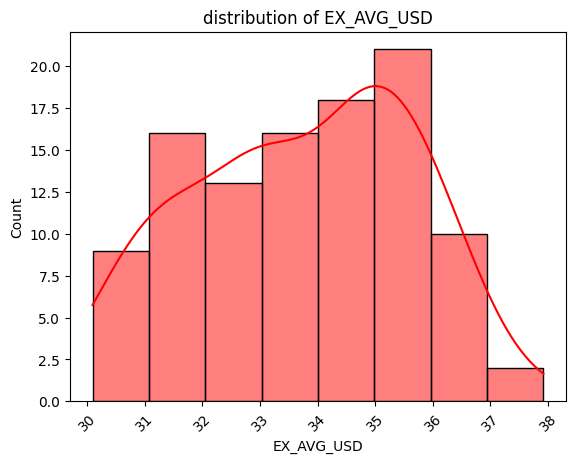

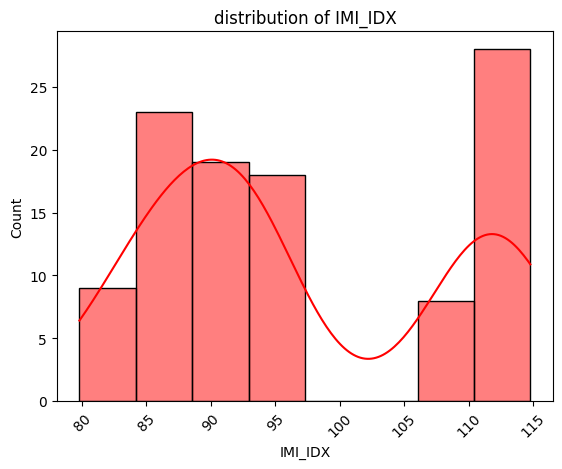

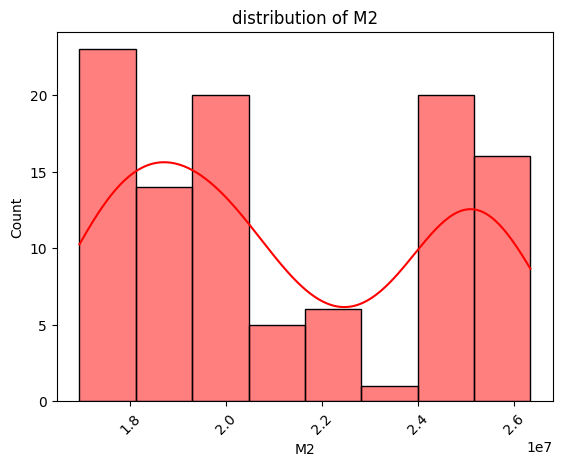

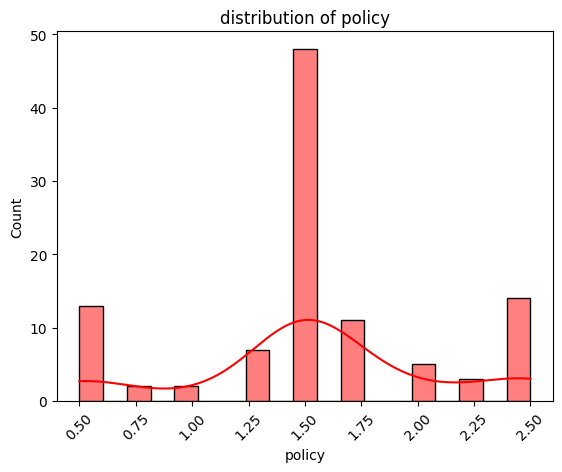

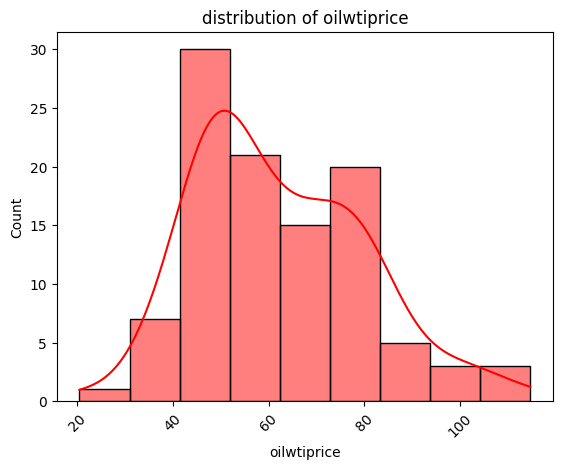

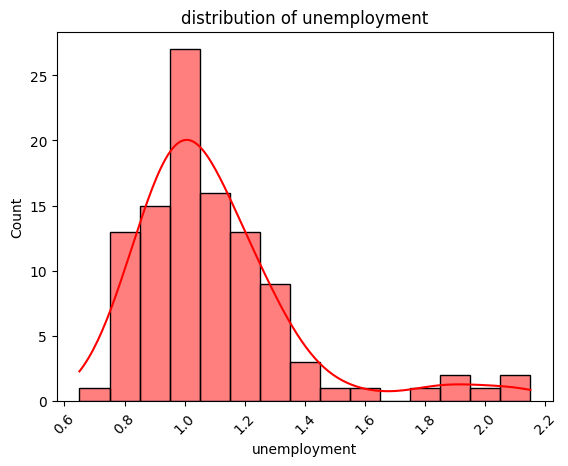

In [ ]:
col = selected_features
for i in col:
    sns.histplot(x= i,data = df,color = "red",kde=True)
    plt.xticks(rotation = 45)
    plt.title("distribution of "+i)
    plt.show()

In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# df['policy'] = df['policy'].astype('category')
# encoder = OneHotEncoder(sparse_output=False)
# encoded_policy = encoder.fit_transform(df[['policy']])
# encoded_policy_df = pd.DataFrame(encoded_policy, columns=encoder.get_feature_names_out(['policy']))
# df = pd.concat([df, encoded_policy_df], axis=1)
# df.drop(columns=['policy'],inplace=True)
# df

In [ ]:
# from sklearn.preprocessing import RobustScaler

# scaler = RobustScaler()
# X_selected.drop(columns=['IMI_IDX'],inplace=True)
# X_scale = X_selected.copy()
# select = X_scale.columns.drop('policy')
# df['IMI_IDX'] = df['IMI_IDX_boxcox']

# for col in select:
#     if X_scale[col].dtype == 'int64' or X_scale[col].dtype == 'float64': # Check for integer type
#         X_scale[col] = scaler.fit_transform(X_scale[[col]])
#         print(f"Applied RobustScaler to column: {col}")
#     else:
#         print(f"Skipped column (not integer): {col}")
# X_scale['policy'] = X_scale['policy'].astype('category')

# display(X_scale.head())

                            OLS Regression Results                            
Dep. Variable:                CPI_IDX   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     779.1
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           8.50e-78
Time:                        08:04:25   Log-Likelihood:                -101.25
No. Observations:                 105   AIC:                             214.5
Df Residuals:                      99   BIC:                             230.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           61.7916      1.315     46.996   

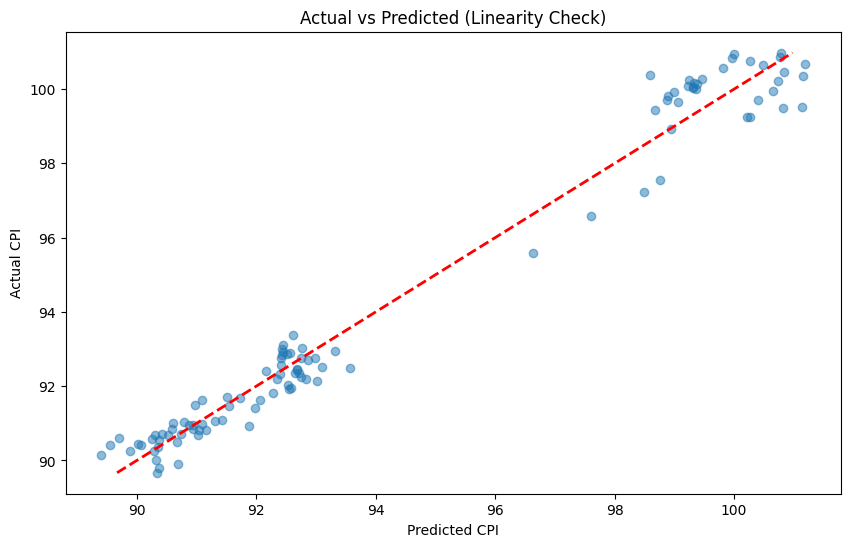

Durbin-Watson statistic: 0.494
{'LM Statistic': np.float64(27.60886627789844), 'LM-Test p-value': np.float64(4.339999908127693e-05), 'F-Statistic': np.float64(7.063542372506602), 'F-Test p-value': np.float64(1.0996546213619385e-05)}

VIF Results:
         Column       VIF
0    EX_AVG_USD  1.236502
1            M2  2.652816
2        policy  2.167651
3   oilwtiprice  2.277529
4  unemployment  2.142020
Shapiro-Wilk Test: Statistic=0.986, p-value=0.3422992169021192


In [ ]:
from sklearn.preprocessing import OneHotEncoder



# encoder = OneHotEncoder()
# encoder.fit(X_selected[['policy']])
# encoded_policy = encoder.transform(X_scale[['policy']])
# encoded_policy_df = pd.DataFrame(encoded_policy.toarray(), columns=encoder.get_feature_names_out(['policy']))
# X_scale = pd.concat([X_scale.drop(columns=['policy']), encoded_policy_df], axis=1)

X_const = sm.add_constant(X_scale)
model = sm.OLS(y, X_const).fit()
print(model.summary())
residuals = model.resid

# 1. Linearity: ตรวจสอบด้วย scatter plot ของ actual vs predicted และ partial regression plots
y_pred = model.predict(X_const)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Predicted CPI')
plt.ylabel('Actual CPI')
plt.title('Actual vs Predicted (Linearity Check)')
plt.show()

from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(model.resid)
print(f'Durbin-Watson statistic: {dw_stat:.3f}')

from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, X_const)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

vif_result = calculate_vif(X_const.drop(columns=['const']))
print("\nVIF Results:")
print(vif_result)

shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: Statistic={shapiro_test.statistic:.3f}, p-value={shapiro_test.pvalue:}')